In [24]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchsummary import summary
from datasets import load_dataset
from torch.utils.data import DataLoader
from fl_torch.task import Net

In [2]:
model_path = "global_model_final.pt"
model = Net()
model.load_state_dict(torch.load(model_path))
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
            Conv2d-3           [-1, 32, 32, 32]           9,248
       BatchNorm2d-4           [-1, 32, 32, 32]              64
         MaxPool2d-5           [-1, 32, 16, 16]               0
           Dropout-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
       BatchNorm2d-8           [-1, 64, 16, 16]             128
            Conv2d-9           [-1, 64, 16, 16]          36,928
      BatchNorm2d-10           [-1, 64, 16, 16]             128
        MaxPool2d-11             [-1, 64, 8, 8]               0
          Dropout-12             [-1, 64, 8, 8]               0
           Conv2d-13            [-1, 128, 8, 8]          73,856
      BatchNorm2d-14            [-1, 12

C:\Users\Tien Dung\AppData\Local\Temp\ipykernel_20720\3554572820.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


In [3]:
testset = load_dataset("uoft-cs/cifar10", split="test")
classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")
transform = Compose([ToTensor(), Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [4]:
test_images = np.array([np.array(testset[i]["img"]) for i in range(len(testset))])
test_labels = np.array([testset[i]["label"] for i in range(len(testset))])

print("Shape of test images:", test_images.shape)
print("Shape of test labels:", test_labels.shape)
print("Unique labels:", np.unique(test_labels))

Shape of test images: (10000, 32, 32, 3)
Shape of test labels: (10000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


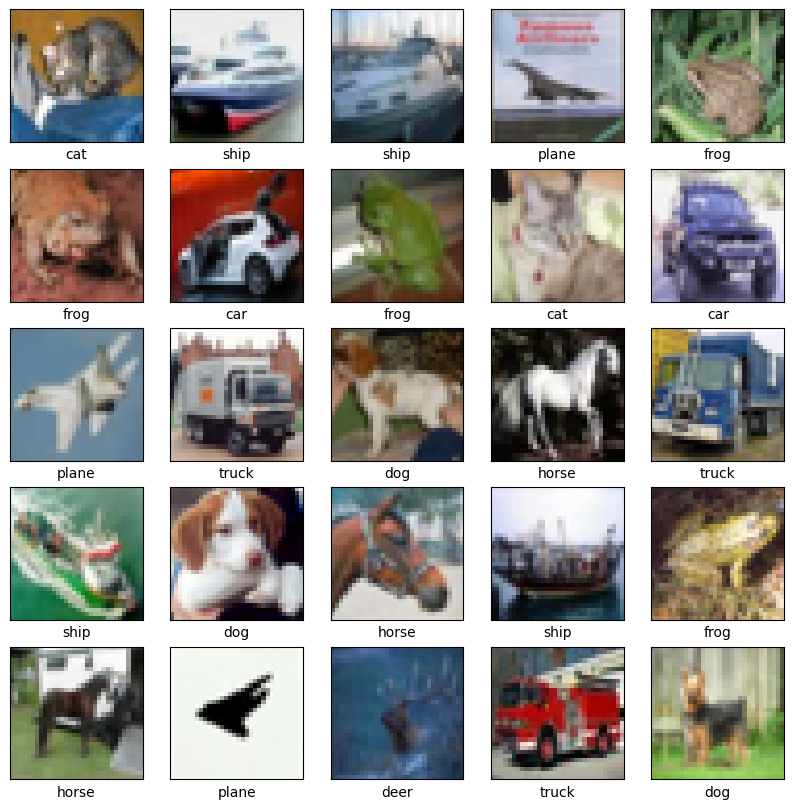

In [5]:
images = [(transform(testset[i]["img"]).permute(1, 2, 0) * 0.5 + 0.5).numpy() for i in range(25)]
labels = [testset[i]["label"] for i in range(25)]

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images[i])
    plt.xlabel(classes[labels[i]])

plt.show()

In [6]:
def apply_transform(batch):
    batch["img"] = [transform(img) for img in batch["img"]]
    return batch

testloader = DataLoader(testset.with_transform(apply_transform), batch_size=32, shuffle=False)

In [7]:
criterion = nn.CrossEntropyLoss()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for batch in testloader:
        images = batch["img"].to(device)
        labels = batch["label"].to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_loss /= len(testloader)
accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.5928
Test Accuracy: 79.49%


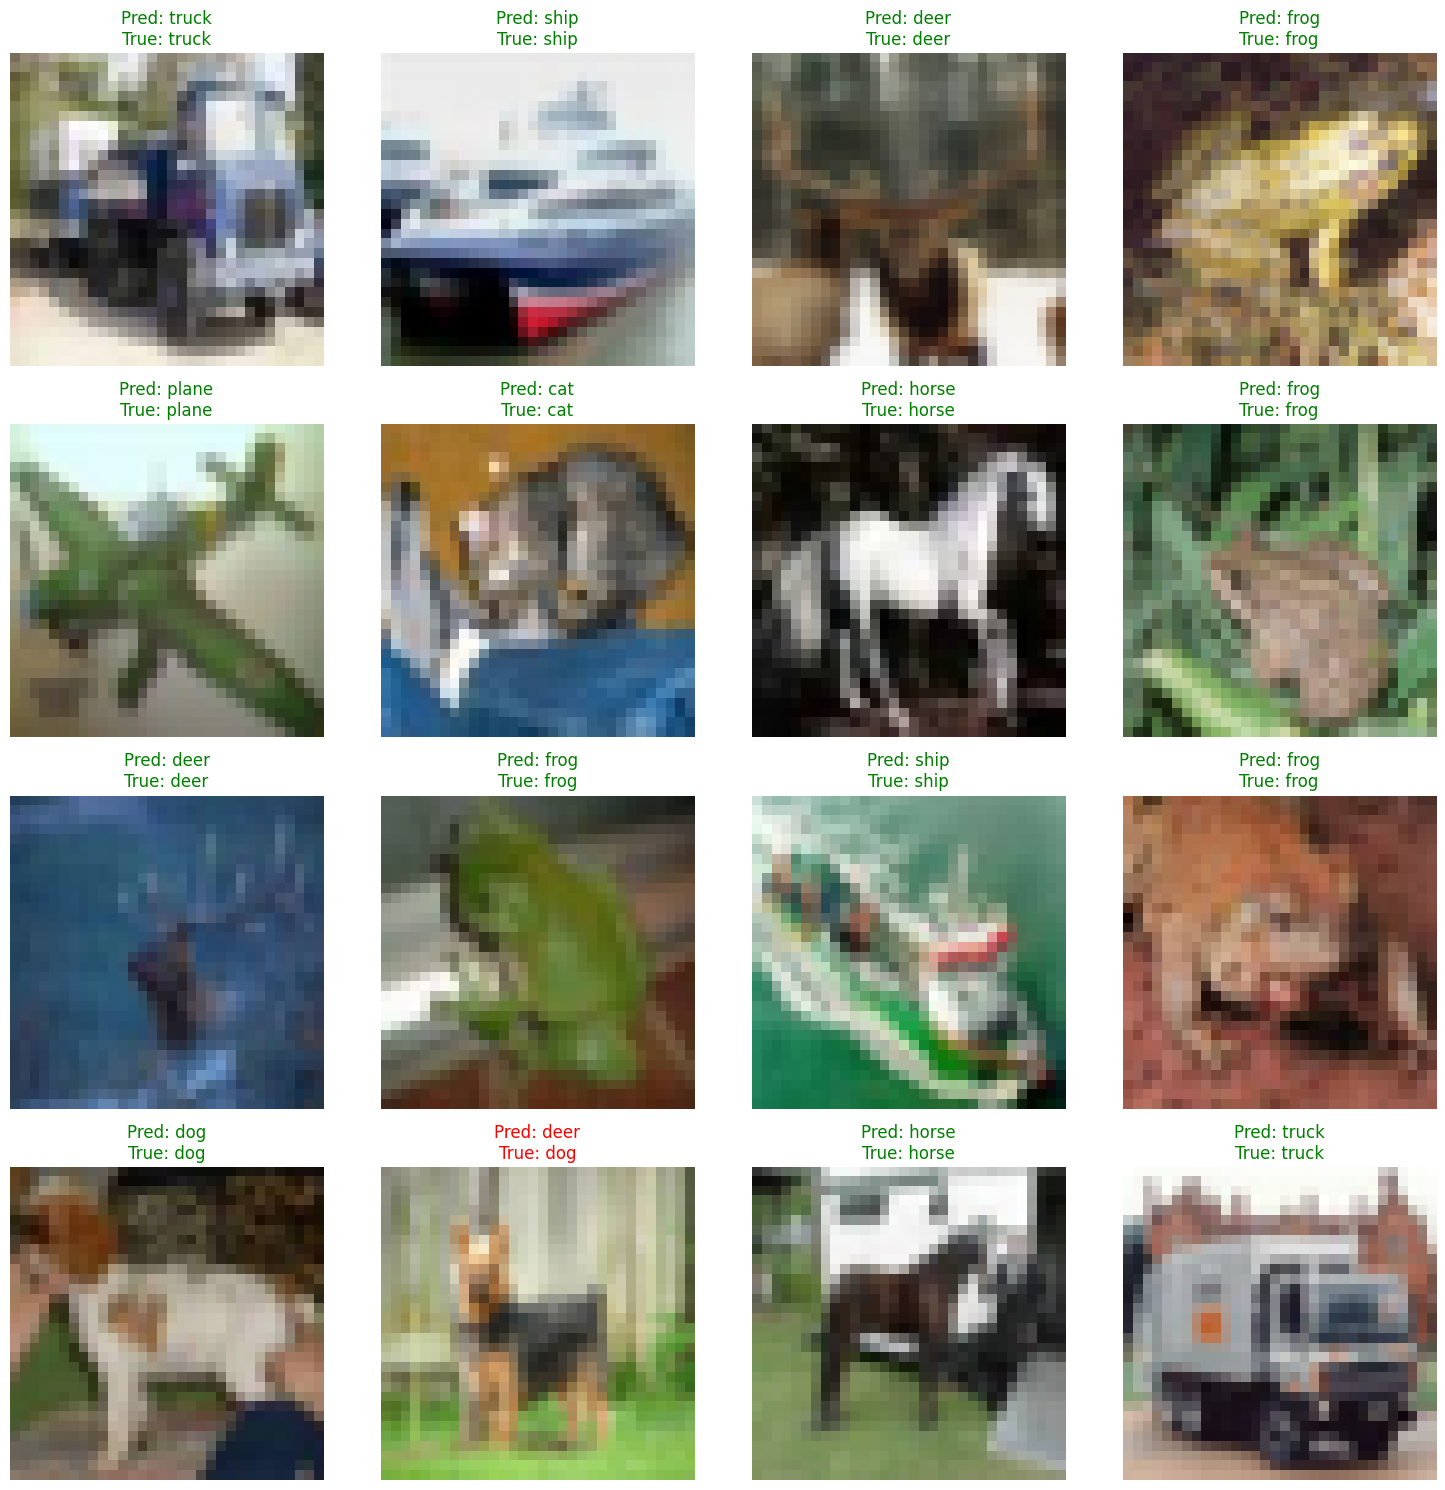

In [8]:
import random

def show_batch_predictions(model, testloader, device, num_images=16):
    model.eval()
    batch = next(iter(testloader))
    images = batch["img"].to(device)
    labels = batch["label"].to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
    
    images = images.cpu()
    labels = labels.cpu()
    predicted = predicted.cpu()

    total_images = len(images)
    random_indices = random.sample(range(total_images), num_images)
    
    plt.figure(figsize=(15, 15))
    for plot_pos, img_idx in enumerate(random_indices, start=1):
        plt.subplot(4, 4, plot_pos)
        img = images[img_idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
        plt.imshow(np.clip(img, 0, 1))
        color = "green" if predicted[img_idx] == labels[img_idx] else "red"
        plt.title(f"Pred: {classes[predicted[img_idx]]}\nTrue: {classes[labels[img_idx]]}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch_predictions(model, testloader, device)

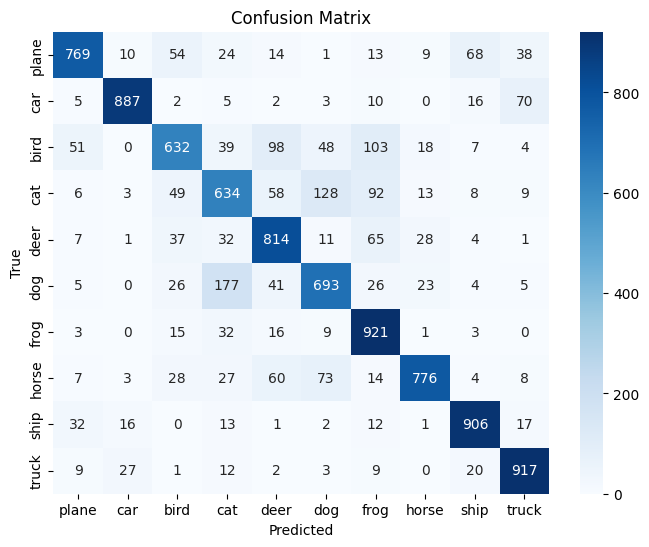

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, testloader, device):
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["img"].to(device), batch["label"].to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

plot_confusion_matrix(model, testloader, device)

FileUpload(value=(), accept='.jpg,.png', description='Upload')

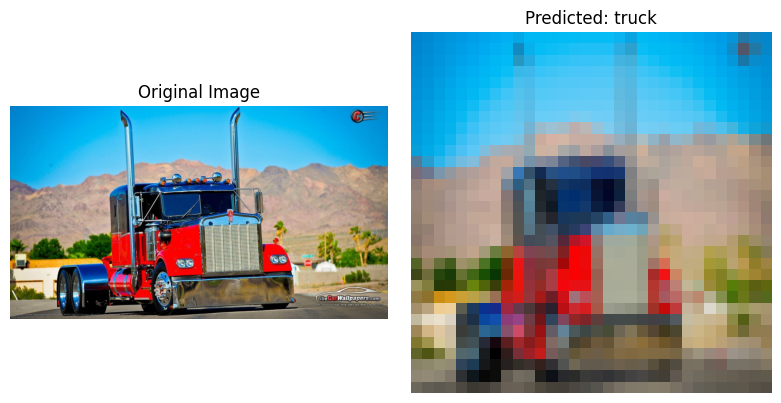

In [ ]:
from PIL import Image
import ipywidgets as widgets
import io

def predict_custom_image(model, device):
    upload = widgets.FileUpload(accept=".jpg,.png", multiple=False)
    display(upload)
    
    def on_upload_change(change):
        if upload.value:
            img_data = upload.value[0]["content"]
            img = Image.open(io.BytesIO(img_data)).convert("RGB")

            preprocess = Compose([
                        Resize((32, 32)),
                        ToTensor(),
                        Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])
            img_tensor = preprocess(img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                output = model(img_tensor)
                _, predicted = torch.max(output, 1)
            
            plt.figure(figsize=(8, 4))
            plt.subplot(1, 2, 1)
            plt.imshow(img)
            plt.title("Original Image")
            plt.axis("off")
            
            plt.subplot(1, 2, 2)
            plt.imshow(img_tensor.squeeze().cpu().permute(1, 2, 0).numpy() * 0.5 + 0.5)
            plt.title(f"Predicted: {classes[predicted.item()]}")
            plt.axis("off")
            
            plt.tight_layout()
            plt.show()

    upload.observe(on_upload_change, names="value")

predict_custom_image(model, device)

FileUpload(value=(), accept='.jpg,.png', description='Upload')

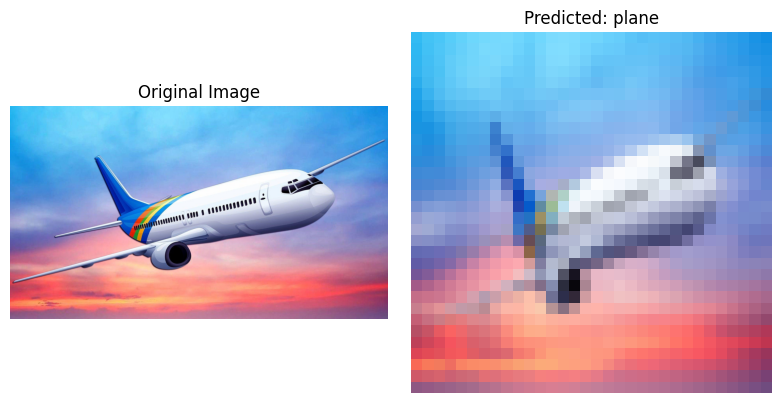

In [ ]:
predict_custom_image(model, device)

FileUpload(value=(), accept='.jpg,.png', description='Upload')

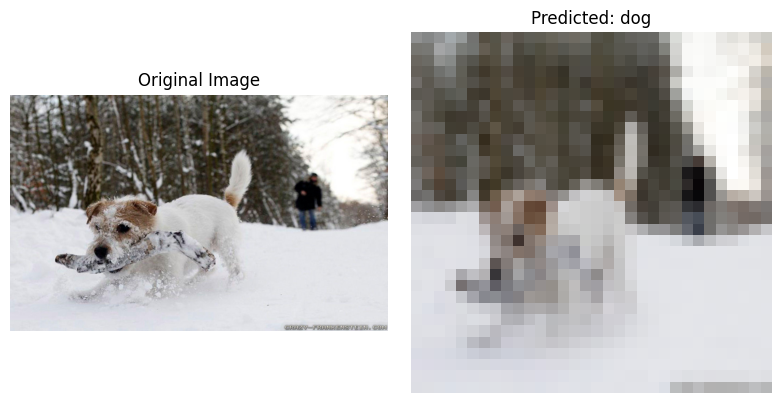

In [ ]:
predict_custom_image(model, device)